## Claude

C:\Users\gabri\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


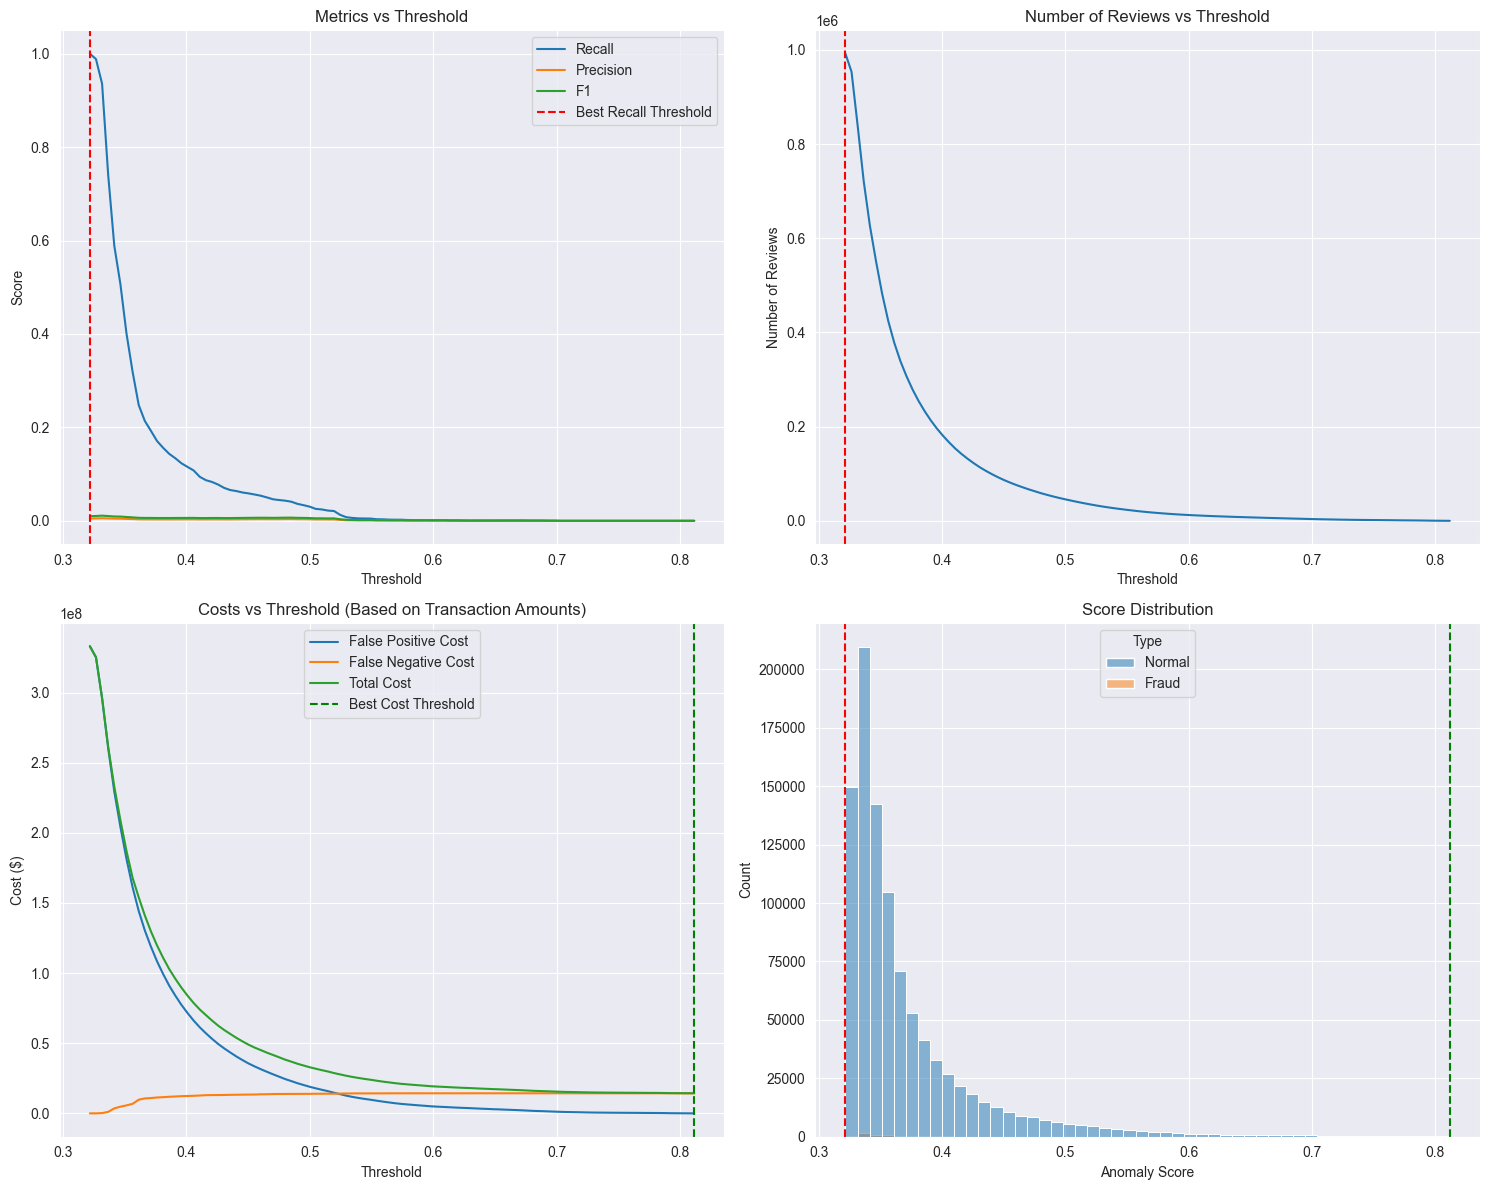


Best Threshold for Maximum Recall:
Threshold: 0.3217
Recall: 1.0000
Precision: 0.0050
F1-Score: 0.0100
Number of Reviews: 991964.0
Caught Frauds: 5009.0
Missed Frauds: 0.0
False Positive Cost: $333,023,623.60
False Negative Cost: $0.00
Total Cost: $333,023,623.60

Best Threshold for Minimum Cost:
Threshold: 0.8116
Recall: 0.0000
Precision: 0.0000
F1-Score: 0.0000
Number of Reviews: 0.0
Caught Frauds: 0.0
Missed Frauds: 5009.0
False Positive Cost: $0.00
False Negative Cost: $14,310,661.76
Total Cost: $14,310,661.76


In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.metrics import recall_score, precision_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

def train_and_analyze_isolation_forest(df, n_thresholds=100):
    """
    Train Isolation Forest and analyze different thresholds with dynamic costs
    """
    # Prepare features
    X = df.drop(['infraction', 'event_created_at', 'merchant_id'], axis=1)
    y = df['infraction']
    amounts = df['amount']

    # Train Isolation Forest
    iso_forest = IsolationForest(
        n_estimators=100,
        max_samples='auto',
        contamination='auto',
        random_state=42,
        n_jobs=-1
    )

    # Fit and get anomaly scores
    iso_forest.fit(X)
    scores = -iso_forest.score_samples(X)  # Negative scores so higher = more anomalous

    # Analyze different thresholds
    thresholds = np.linspace(scores.min(), scores.max(), n_thresholds)
    results = []

    for threshold in thresholds:
        # Predict anomalies based on threshold
        predictions = (scores > threshold).astype(int)

        # Calculate metrics
        recall = recall_score(y, predictions)
        precision = precision_score(y, predictions)
        f1 = f1_score(y, predictions)

        # Calculate costs using transaction amounts
        # False Positives: unnecessarily reviewed transactions (cost = transaction amount)
        fp_mask = (predictions == 1) & (y == 0)
        fp_cost = amounts[fp_mask].sum()

        # False Negatives: missed frauds (cost = transaction amount)
        fn_mask = (predictions == 0) & (y == 1)
        fn_cost = amounts[fn_mask].sum()

        # Calculate total cost
        total_cost = fp_cost + fn_cost

        # Count transactions for reporting
        n_reviews = sum(predictions)
        n_caught_frauds = sum((predictions == 1) & (y == 1))
        n_missed_frauds = sum((predictions == 0) & (y == 1))

        results.append({
            'threshold': threshold,
            'recall': recall,
            'precision': precision,
            'f1_score': f1,
            'n_reviews': n_reviews,
            'n_caught_frauds': n_caught_frauds,
            'n_missed_frauds': n_missed_frauds,
            'fp_cost': fp_cost,
            'fn_cost': fn_cost,
            'total_cost': total_cost
        })

    results_df = pd.DataFrame(results)

    # Find optimal threshold based on recall
    best_recall_idx = results_df['recall'].idxmax()
    best_threshold = results_df.loc[best_recall_idx, 'threshold']

    # Find optimal threshold based on cost
    best_cost_idx = results_df['total_cost'].idxmin()
    best_cost_threshold = results_df.loc[best_cost_idx, 'threshold']

    # Plot results
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

    # Plot 1: Metrics vs Threshold
    ax1.plot(results_df['threshold'], results_df['recall'], label='Recall')
    ax1.plot(results_df['threshold'], results_df['precision'], label='Precision')
    ax1.plot(results_df['threshold'], results_df['f1_score'], label='F1')
    ax1.axvline(best_threshold, color='r', linestyle='--', label='Best Recall Threshold')
    ax1.set_title('Metrics vs Threshold')
    ax1.set_xlabel('Threshold')
    ax1.set_ylabel('Score')
    ax1.legend()

    # Plot 2: Number of Reviews vs Threshold
    ax2.plot(results_df['threshold'], results_df['n_reviews'])
    ax2.axvline(best_threshold, color='r', linestyle='--', label='Best Recall Threshold')
    ax2.set_title('Number of Reviews vs Threshold')
    ax2.set_xlabel('Threshold')
    ax2.set_ylabel('Number of Reviews')

    # Plot 3: Costs vs Threshold
    ax3.plot(results_df['threshold'], results_df['fp_cost'], label='False Positive Cost')
    ax3.plot(results_df['threshold'], results_df['fn_cost'], label='False Negative Cost')
    ax3.plot(results_df['threshold'], results_df['total_cost'], label='Total Cost')
    ax3.axvline(best_cost_threshold, color='g', linestyle='--', label='Best Cost Threshold')
    ax3.set_title('Costs vs Threshold (Based on Transaction Amounts)')
    ax3.set_xlabel('Threshold')
    ax3.set_ylabel('Cost ($)')
    ax3.legend()

    # Plot 4: Score Distribution
    sns.histplot(data=pd.DataFrame({
        'Anomaly Score': scores,
        'Type': ['Fraud' if y == 1 else 'Normal' for y in df['infraction']]
    }), x='Anomaly Score', hue='Type', bins=50, ax=ax4)
    ax4.axvline(best_threshold, color='r', linestyle='--', label='Best Recall Threshold')
    ax4.axvline(best_cost_threshold, color='g', linestyle='--', label='Best Cost Threshold')
    ax4.set_title('Score Distribution')

    plt.tight_layout()
    plt.show()

    # Print summary for best recall threshold
    print("\nBest Threshold for Maximum Recall:")
    best_recall_results = results_df.iloc[best_recall_idx]
    print(f"Threshold: {best_recall_results['threshold']:.4f}")
    print(f"Recall: {best_recall_results['recall']:.4f}")
    print(f"Precision: {best_recall_results['precision']:.4f}")
    print(f"F1-Score: {best_recall_results['f1_score']:.4f}")
    print(f"Number of Reviews: {best_recall_results['n_reviews']}")
    print(f"Caught Frauds: {best_recall_results['n_caught_frauds']}")
    print(f"Missed Frauds: {best_recall_results['n_missed_frauds']}")
    print(f"False Positive Cost: ${best_recall_results['fp_cost']:,.2f}")
    print(f"False Negative Cost: ${best_recall_results['fn_cost']:,.2f}")
    print(f"Total Cost: ${best_recall_results['total_cost']:,.2f}")

    # Print summary for best cost threshold
    print("\nBest Threshold for Minimum Cost:")
    best_cost_results = results_df.iloc[best_cost_idx]
    print(f"Threshold: {best_cost_results['threshold']:.4f}")
    print(f"Recall: {best_cost_results['recall']:.4f}")
    print(f"Precision: {best_cost_results['precision']:.4f}")
    print(f"F1-Score: {best_cost_results['f1_score']:.4f}")
    print(f"Number of Reviews: {best_cost_results['n_reviews']}")
    print(f"Caught Frauds: {best_cost_results['n_caught_frauds']}")
    print(f"Missed Frauds: {best_cost_results['n_missed_frauds']}")
    print(f"False Positive Cost: ${best_cost_results['fp_cost']:,.2f}")
    print(f"False Negative Cost: ${best_cost_results['fn_cost']:,.2f}")
    print(f"Total Cost: ${best_cost_results['total_cost']:,.2f}")

    return iso_forest, results_df, scores

raw_transactions = pd.read_csv('../data/processed/raw_transactions.csv')
# Run the analysis
iso_forest, results_df, scores = train_and_analyze_isolation_forest(raw_transactions)

## ChatGPT

Anomaly score range: -0.017383351397936564 to 0.47253172214887124

Cost Analysis for different thresholds:
   threshold  Recall  Precision  F1-Score  TP    FN    FP      TN  \
0  -0.017383     0.0        0.0       0.0   0  5009     0  986956   
1  -0.007385     0.0        0.0       0.0   0  5009   226  986730   
2   0.002613     0.0        0.0       0.0   0  5009   575  986381   
3   0.012611     0.0        0.0       0.0   0  5009   883  986073   
4   0.022610     0.0        0.0       0.0   0  5009  1090  985866   

   Cost_FN_total  Cost_FP_total   Total Cost  
0    14310661.76           0.00  14310661.76  
1    14310661.76       55094.00  14365755.76  
2    14310661.76      132962.30  14443624.06  
3    14310661.76      266510.08  14577171.84  
4    14310661.76      314163.08  14624824.84  

Best threshold by Recall:
threshold        4.725317e-01
Recall           1.000000e+00
Precision        5.049578e-03
F1-Score         1.004842e-02
TP               5.009000e+03
FN               0.

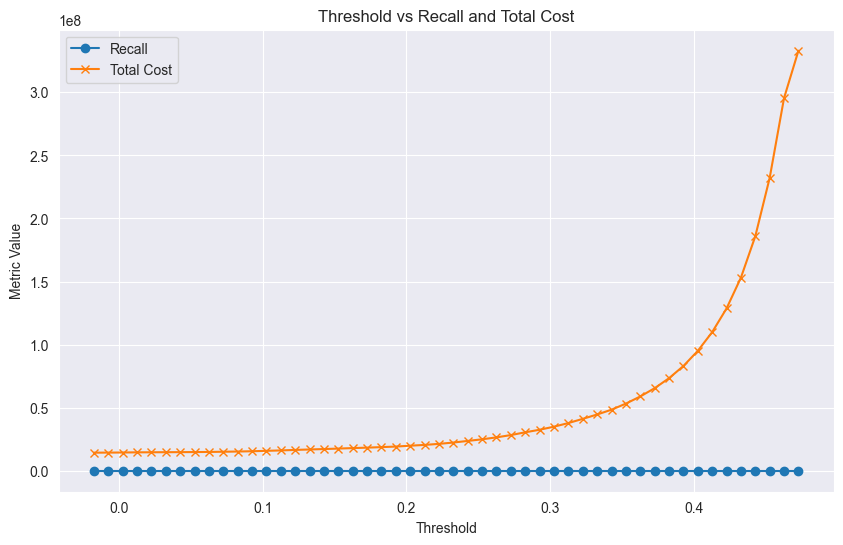

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix

# -------------------------------
# 1. Load Data and Train Isolation Forest
# -------------------------------
# Assume raw_prediction is loaded (for example, using pd.read_parquet or pd.read_csv)
df = pd.read_csv('../data/processed/raw_transactions.csv').copy()

# Save the target and the transaction amount for cost calculation.
# Do not drop the "amount" column if you want to use it for cost analysis.
y = df['infraction']
# For cost analysis, we assume df has a column "amount" which holds the transaction amount.
amounts = df['amount'].reset_index(drop=True)

# Prepare features: drop non-predictive columns (target, timestamp, merchant id).
# Do not drop "amount" because we want to use it both as a feature and for cost computation.
X = df.drop(['infraction', 'event_created_at', 'merchant_id'], axis=1)
# Reset index so that X, y, and amounts align
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

# Train Isolation Forest on raw features (without scaling)
# Set contamination to an estimate of the fraud ratio (e.g., 0.0005 for 0.05% fraud)
iso_model = IsolationForest(n_estimators=100, contamination=0.0005, random_state=42)
iso_model.fit(X)

# Compute anomaly scores using decision_function.
# Note: decision_function gives higher values for inliers and lower for anomalies.
scores = iso_model.decision_function(X)
df['anomaly_score'] = scores  # Save for later analysis

print("Anomaly score range:", scores.min(), "to", scores.max())

# -------------------------------
# 2. Threshold Sweep and Cost Analysis
# -------------------------------
# Define a set of candidate thresholds over the range of anomaly scores.
thresholds = np.linspace(scores.min(), scores.max(), num=50)

results = []

# Reset y (target) index for consistency.
y_reset = y.reset_index(drop=True)

for thresh in thresholds:
    # Predict fraud (1) if the anomaly score is less than the threshold; else 0.
    y_pred = (scores < thresh).astype(int)

    # Compute evaluation metrics
    rec = recall_score(y_reset, y_pred, zero_division=0)
    prec = precision_score(y_reset, y_pred, zero_division=0)
    f1 = f1_score(y_reset, y_pred, zero_division=0)

    # Compute confusion matrix counts:
    tn, fp, fn, tp = confusion_matrix(y_reset, y_pred).ravel()

    # Now, compute cost using the transaction amounts.
    # For each false negative (FN): a fraudulent transaction (y==1) that is predicted normal (y_pred==0)
    fn_indices = np.where((y_reset == 1) & (y_pred == 0))[0]
    # For each false positive (FP): a normal transaction (y==0) that is predicted fraud (y_pred==1)
    fp_indices = np.where((y_reset == 0) & (y_pred == 1))[0]

    # For each misclassified transaction, cost is the transaction amount.
    cost_FN_total = amounts.iloc[fn_indices].sum()   # total amount missed for frauds
    cost_FP_total = amounts.iloc[fp_indices].sum()     # total amount for false alarms
    total_cost = cost_FN_total + cost_FP_total

    results.append({
        'threshold': thresh,
        'Recall': rec,
        'Precision': prec,
        'F1-Score': f1,
        'TP': tp,
        'FN': fn,
        'FP': fp,
        'TN': tn,
        'Cost_FN_total': cost_FN_total,
        'Cost_FP_total': cost_FP_total,
        'Total Cost': total_cost
    })

results_df = pd.DataFrame(results)
print("\nCost Analysis for different thresholds:")
print(results_df.head())

# Identify the threshold that maximizes recall and the one that minimizes total cost.
best_recall = results_df.loc[results_df['Recall'].idxmax()]
best_cost = results_df.loc[results_df['Total Cost'].idxmin()]

print("\nBest threshold by Recall:")
print(best_recall)
print("\nBest threshold by Total Cost:")
print(best_cost)

# -------------------------------
# 3. Plot Metrics and Cost vs. Threshold
# -------------------------------
plt.figure(figsize=(10, 6))
plt.plot(results_df['threshold'], results_df['Recall'], marker='o', label='Recall')
plt.plot(results_df['threshold'], results_df['Total Cost'], marker='x', label='Total Cost')
plt.xlabel('Threshold')
plt.ylabel('Metric Value')
plt.legend()
plt.title("Threshold vs Recall and Total Cost")
plt.grid(True)
plt.show()


## DeepSeek

Anomaly score range: -0.0174 to 0.4725

Cost analysis for various thresholds:
   threshold  Recall  Precision  F1-Score  TP    FN    FP      TN  \
0  -0.017383     0.0        0.0       0.0   0  5009     0  986956   
1  -0.007385     0.0        0.0       0.0   0  5009   226  986730   
2   0.002613     0.0        0.0       0.0   0  5009   575  986381   
3   0.012611     0.0        0.0       0.0   0  5009   883  986073   
4   0.022610     0.0        0.0       0.0   0  5009  1090  985866   

   Cost_FN_total  Cost_FP_total   Total Cost  
0    14310661.76           0.00  14310661.76  
1    14310661.76       55094.00  14365755.76  
2    14310661.76      132962.30  14443624.06  
3    14310661.76      266510.08  14577171.84  
4    14310661.76      314163.08  14624824.84  

Best threshold by Recall:
threshold        4.725317e-01
Recall           1.000000e+00
Precision        5.049578e-03
F1-Score         1.004842e-02
TP               5.009000e+03
FN               0.000000e+00
FP               9

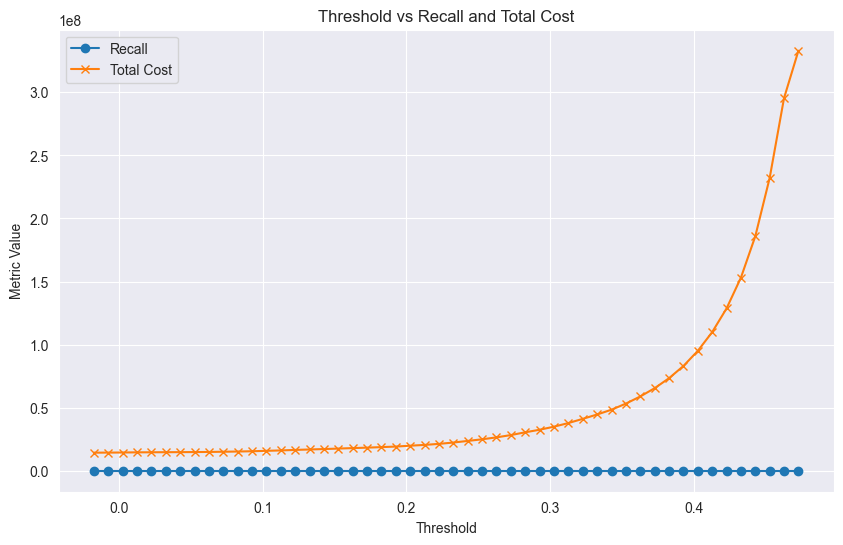

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix

# -------------------------------
# 1. Load Data and Prepare Features
# -------------------------------
# Assume raw_prediction is your dataframe already loaded.
df = pd.read_csv('../data/processed/raw_transactions.csv').copy()

# Save the target ("infraction") and the transaction "amount" for cost calculation.
y = df['infraction'].reset_index(drop=True)
amounts = df['amount'].reset_index(drop=True)

# Prepare features by dropping non-predictive columns.
# Note: We keep "amount" as a feature (and also for cost calculation).
X = df.drop(['infraction', 'event_created_at', 'merchant_id'], axis=1).reset_index(drop=True)

# -------------------------------
# 2. Train Isolation Forest on the Whole Dataset (Unsupervised)
# -------------------------------
# Set contamination to an estimated fraud ratio (e.g., 0.0005 for 0.05% fraud).
iso_model = IsolationForest(n_estimators=100, contamination=0.0005, random_state=42)
iso_model.fit(X)

# Compute anomaly scores using the decision_function.
# Note: Higher values indicate inliers; lower values indicate anomalies.
scores = iso_model.decision_function(X)
df['anomaly_score'] = scores  # Save scores for further analysis.

print("Anomaly score range: {:.4f} to {:.4f}".format(scores.min(), scores.max()))

# -------------------------------
# 3. Experiment with Different Thresholds and Perform Cost Analysis
# -------------------------------
# We define a range of thresholds spanning the range of anomaly scores.
thresholds = np.linspace(scores.min(), scores.max(), num=50)

results = []

# For evaluation, use the ground truth labels y.
# For each threshold, we compute:
# - Recall, Precision, F1-Score.
# - Confusion matrix counts.
# - The total cost: for each false negative and false positive,
#   we assume the cost is the transaction's amount.

for thresh in thresholds:
    # If the anomaly score is less than the threshold, flag as fraud (1); otherwise normal (0).
    y_pred = (scores < thresh).astype(int)

    # Compute standard metrics.
    rec = recall_score(y, y_pred, zero_division=0)
    prec = precision_score(y, y_pred, zero_division=0)
    f1 = f1_score(y, y_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

    # Identify misclassifications.
    fn_indices = np.where((y == 1) & (y_pred == 0))[0]  # Missed frauds.
    fp_indices = np.where((y == 0) & (y_pred == 1))[0]  # False alarms.

    # Calculate cost: each misclassified transaction costs the transaction amount.
    cost_FN_total = amounts.iloc[fn_indices].sum()
    cost_FP_total = amounts.iloc[fp_indices].sum()
    total_cost = cost_FN_total + cost_FP_total

    results.append({
        'threshold': thresh,
        'Recall': rec,
        'Precision': prec,
        'F1-Score': f1,
        'TP': tp,
        'FN': fn,
        'FP': fp,
        'TN': tn,
        'Cost_FN_total': cost_FN_total,
        'Cost_FP_total': cost_FP_total,
        'Total Cost': total_cost
    })

results_df = pd.DataFrame(results)
print("\nCost analysis for various thresholds:")
print(results_df.head())

# Identify the threshold that maximizes recall and the one that minimizes total cost.
best_recall = results_df.loc[results_df['Recall'].idxmax()]
best_cost = results_df.loc[results_df['Total Cost'].idxmin()]

print("\nBest threshold by Recall:")
print(best_recall)
print("\nBest threshold by Total Cost:")
print(best_cost)

# -------------------------------
# 4. Visualization: Metrics vs. Threshold
# -------------------------------
plt.figure(figsize=(10, 6))
plt.plot(results_df['threshold'], results_df['Recall'], marker='o', label='Recall')
plt.plot(results_df['threshold'], results_df['Total Cost'], marker='x', label='Total Cost')
plt.xlabel('Threshold')
plt.ylabel('Metric Value')
plt.title("Threshold vs Recall and Total Cost")
plt.legend()
plt.grid(True)
plt.show()
